In [2]:
import numpy as np
import math
from tqdm import tqdm

%matplotlib ipympl

# from scipy import signal
import util as U
import config as C
from experiments import *
import matplotlib.pyplot as plt

def show_file(filename):
    HZ_DIV = 2
    # LOW_FREQ = C.P.TOTAL_MINHZ
    file = U.WaveReader(filename)
    HZ = file.hz / HZ_DIV
    # WIN_SIZE = 1<<round(math.ceil(math.log2(HZ / LOW_FREQ)))
    WIN_SIZE = round(C.P.MIN_FREQTIME * HZ)
    whole_file = np.concat(tuple(i[::HZ_DIV] for i in file))
    file.close()
    coords = np.arange(len(whole_file), dtype=C.TY)/HZ
    figure, (spec, aud) = plt.subplots(2, sharex=True)
    figure.title = filename
    spec.specgram(whole_file, pad_to=WIN_SIZE*2, Fs=HZ, NFFT=WIN_SIZE, noverlap=WIN_SIZE - WIN_SIZE//6)
    aud.plot(coords, whole_file)


## Frequency finding experiment

In [4]:
def find_peak_freq(dft, hz, expn):
    """
    Warning: you can only call this when there is a singular peak!
    """
    as_weights = dft / np.sum(dft) * 4
    as_weights = as_weights**expn
    as_weights = as_weights / np.sum(as_weights)

    index = np.sum(np.arange(len(dft)) * as_weights)
    return U.bin2hz(index, len(dft), hz)

hz = 44100
wsize = hz // 50
targets = np.arange(C.P.TOTAL_MINHZ, C.P.TOTAL_MAXHZ, 50, dtype=C.TY)
waveforms = [
    U.afft(np.sin(np.arange(wsize, dtype=C.TY) * target / hz * np.pi * 2))
    for target in tqdm(targets)
]
expnts = np.log2(np.linspace(2**1, 2**18, 40, dtype=C.TY))

best_expnts = []
divnumbers = []

for target, data in tqdm(list(zip(targets, waveforms))):
    best = (hz, expnts[0])
    for expnt in expnts:
        peak = find_peak_freq(data, hz, expnt)
        if abs(peak - target) < best[0]:
            best = (abs(peak - target), expnt)

    divnumbers.append(4 / np.sum(data))
    best_expnts.append(best[1])
expnt = np.mean(best_expnts)

errors = []

for target, data in zip(targets, waveforms):
    peak = find_peak_freq(data, hz, expnt)
    errors.append(peak - target)

print("Best exponent:")
gauss(best_expnts)
print("Best multiplication constant for data:")
p_ile(divnumbers, 99.5, r=True)
gauss(divnumbers)
print("Frequency error for best exponent:")
p_ile(np.abs(errors), [50, 95, 99.5])
gauss(errors)



100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 216/216 [00:00<00:00, 553.04it/s]


Best exponent:
12.715015 ± 1.9073486e-06 2σ
Best multiplication constant for data:
99.5th %ile: 0.009065905
0.009068139 ± 2.4770636e-06 2σ
Frequency error for best exponent:
50th %ile: 0.0
95th %ile: 0.0
99.5th %ile: 0.0
0.0 ± 0.0 2σ


(np.float64(0.0), np.float64(0.0))

## Time base frequency isolation experiment

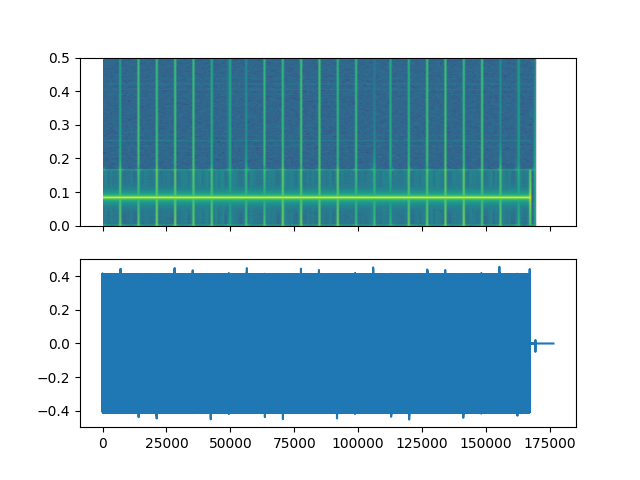

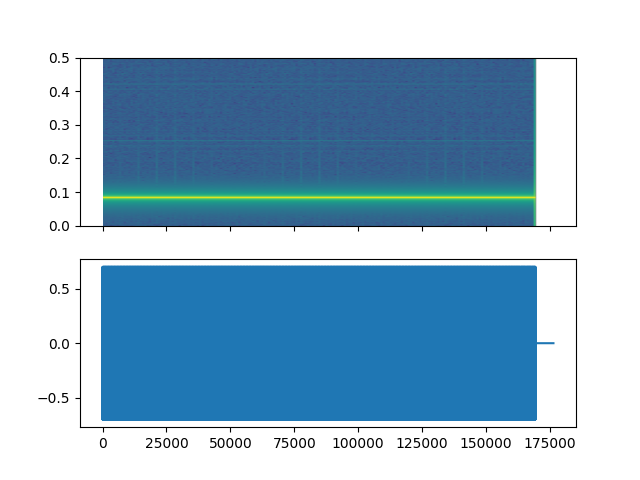

In [7]:
file = U.WaveReader(C.AUD_OUT_PATH, C.WIN_SIZE * 32, "samples")
hz = file.hz
tbc_file = U.WaveWriter("./tbc_isolate.wav", 2, hz, np.int16)
approxi_file = U.WaveWriter("./approxi.wav", 2, hz, np.int16)

for chunk in file:
    tbc_isolate = U.bandpass(chunk, hz, C.P.TBC_LOW, C.P.TBC_HIGH)
    tbc_file.write(tbc_isolate)
    freq = U.find_peak_freq(tbc_isolate, hz, C.P.TBC_FREQ)
    approxi_file.write(np.sin(np.arange(C.WIN_SIZE * 32) * (freq / hz * np.pi * 2)))

file.close()
tbc_file.close()
approxi_file.close()

show_file("./tbc_isolate.wav")
show_file("./approxi.wav")


## Frequency finding with zero-crossing experiment

10100.02 ± 12.770038 2σ


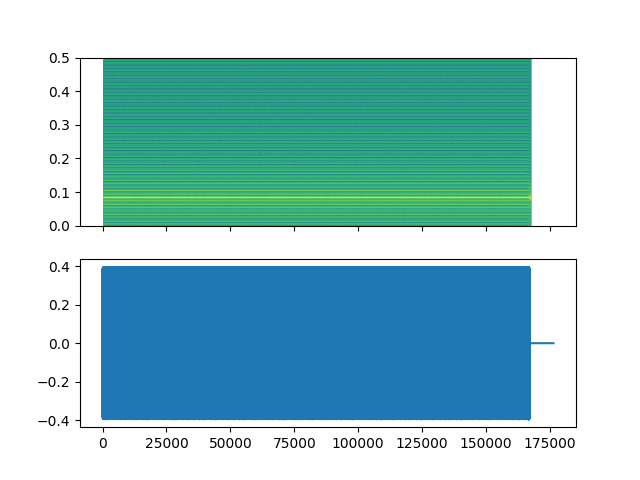

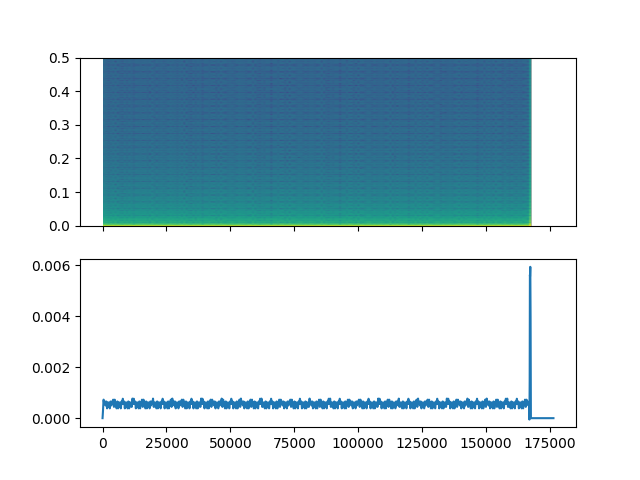

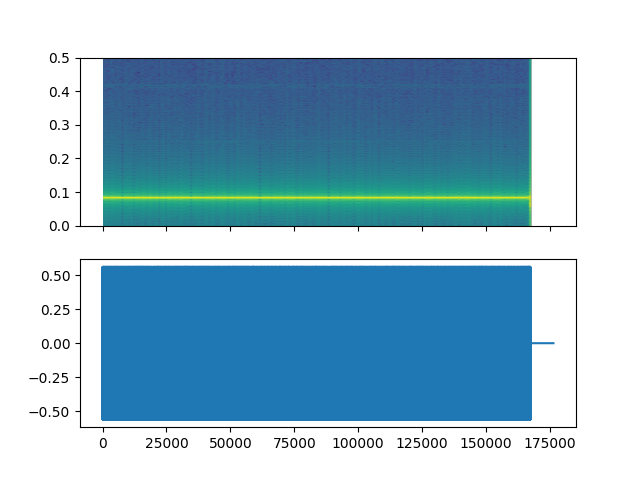

In [12]:
def find_zxings(signal):
    sign = np.sign(signal)
    change = sign - np.roll(sign, 1)
    change = change[1:]
    zxings = np.arange(len(change), dtype=C.TY)[change > 0.5]
    return zxings

expected_freq = C.P.TBC_FREQ
WIN_SIZE = C.WIN_SIZE
ROLL_SIZE = C.WIN_ROFF
WIN_SIZE *= 2

file = U.WaveReader(C.AUD_OUT_PATH, WIN_SIZE, "samples")
hz = file.hz
file = U.SlidingReader(file, WIN_SIZE, ROLL_SIZE, pad=True)
hz_file = U.WaveWriter("./speed_variation.wav", 4, hz, np.int32)
hz_swrt = U.SlidingWriter(file.basic_mask, file.basic_mask_beginning, ROLL_SIZE, 0)
tbc_file = U.WaveWriter("./tbc_isolate.wav", 2, hz, np.int16)
import modulate

approxi_phaser = modulate.Phaser(0, 1)
approxi_file = U.WaveWriter("./approxi.wav", 2, hz, np.int16)
medians = []
low_bin = U.hz2bin(C.P.TBC_LOW, WIN_SIZE, hz) + 8  # TODO: remove me
high_bin = U.hz2bin(C.P.TBC_HIGH, WIN_SIZE, hz)

for window in file:
    tbc_dft = U.ifft(window)

    # bandpass
    tbc_dft[: low_bin + 1] = 0
    tbc_dft[high_bin:] = 0

    # separate sign & magnitude. to be joined later
    dft_sgn, tbc_dft = np.sign(tbc_dft), np.abs(tbc_dft)

    # remove noise
    tbc_dft -= np.median(tbc_dft[low_bin:high_bin]) * 1.5
    tbc_dft = np.maximum(tbc_dft, 0)

    # rejoin sign & magnitude
    tbc_dft = tbc_dft * dft_sgn

    # turn into time-domain again
    tbc = U.ttf(tbc_dft, len(window))

    # find zero crossings & frequency
    zxings = find_zxings(tbc)
    freq = expected_freq
    if len(zxings) > 2:
        distance = (zxings - np.roll(zxings, 1))[1:]
        distance = np.average(distance)  # samples per cycle
        distance /= hz  # now seconds per cycle
        freq = 1 / distance  # hz
        medians.append(freq)

    hz_file.write(hz_swrt.write(freq / expected_freq - 1))
    tbc_file.write(tbc[:ROLL_SIZE])
    approxi_file.write(approxi_phaser.emit(ROLL_SIZE, freq, 0.8))

hz_file.write(hz_swrt.clean_up())
gauss(medians)

show_file("./tbc_isolate.wav")
show_file("./speed_variation.wav")
show_file("./approxi.wav")



## Control-point finding experiment

In [ ]:
def get_clock_curve(stream):
    sliding_reader = U.SlidingReader(stream, C.P.WIN_SIZE, C.WIN_ROLL)
    mask = sliding_reader.basic_mask
    mask_beg = sliding_reader.basic_mask_beginning
    sli_wri = U.SlidingWriter(mask, mask_beg, C.WIN_ROLL, 0)

    for block in sliding_reader:
        dft = np.abs(U.ifft(block)) / 8
        band1 = np.sum(dft[C.P.bin_bounds[0] : C.P.bin_bounds[1]])
        band2 = np.sum(dft[C.P.bin_bounds[1] : C.P.bin_bounds[2]])

        yield sli_wri.write(band1-band2)

def get_clean_clock_curve(stream):
    roll = C.WIN_ROFF
    clock = U.SlidingReader(get_clock_curve(stream), C.WIN_SIZE, roll)
    smooth_averager = U.SlidingWriter(clock.basic_mask, clock.basic_mask_beginning, roll, 0)
    for block in clock:
        yield block[C.WIN_ROLL] - smooth_averager.write(np.median(block))

# TODO: error correction?
def decode_chunk(chunk, hz, data_residue=None):
    return
    if len(chunk) == 0: return data_residue
    if data_residue is None:
        data_residue = [b"", 0, 0]
    else:
        data_residue = [data_residue[0][:-1], data_residue[1], data_residue[2]]
    bins = [U.hz2bin(freq, C.P.MIN_FREQTIME*hz, hz) for freq in C.P.freq_bounds]
    #print(C.P.DFT_AMP_MUL)
    #print(C.P.freq_bounds, C.P.DFT_AMP_MUL)
    for n_bin in range(2, len(C.P.bin_bounds) - 1):
        # TODO: non-binary bases! (be who you are for your pride dont hide)
        bit = (
            np.sum(U.afft(chunk)[bins[n_bin] : 1 + bins[n_bin+1]])/C.P.DFT_AMP_MUL
            > 1
        )
        bit = 1 if bit else 0
        print("\n", n_bin-1)
        print(bins[n_bin:n_bin+2])
        print(np.sum(U.afft(chunk)[bins[n_bin]:1+bins[n_bin+1]])/C.P.DFT_AMP_MUL, bit)
        data_residue[2] += 1
        data_residue[1] = data_residue[1] << 1 | bit

        if data_residue[2] == 8:
            data_residue[0] += data_residue[1].to_bytes()
            data_residue[1] = 0
            data_residue[2] = 0
#        raise Exception("penis")

    return (
        data_residue[0] + int.to_bytes(data_residue[1] << (8 - data_residue[2])),
        data_residue[1],
        data_residue[2],
    )

ROLL_SIZE = C.WIN_SIZE // 18
WIN_SIZE = round(math.ceil(C.P.MIN_FREQTIME * C.HZ))
buffer_flap_size = C.P.MIN_FREQTIME * C.HZ / 2
max_buffer_size = 12 * buffer_flap_size
# min_block_distance = 1.9*buffer_flap_size

orig_file = U.WaveReader(C.AUD_OUT_PATH, WIN_SIZE, "samples")
hz = orig_file.hz
file = U.StreamSplitter(orig_file)
clock_stream = get_clean_clock_curve(file.split())
clock_stream = U.StreamSplitter(clock_stream).split()
file = file.split()
# clock_stream = U.SlidingReader(get_clean_clock_curve(file.split()), WIN_SIZE, ROLL_SIZE, True)
# file = U.SlidingReader(file.split(), WIN_SIZE, ROLL_SIZE, True)

bit_file = U.WaveWriter("./binary_amp.wav", 2, hz, np.int16)
clock_file = U.WaveWriter("./clock.wav", 2, hz, np.int16)

last_sign_change = 0
last_sign = None
buffer = np.zeros(WIN_SIZE, dtype=np.float32)
inx = WIN_SIZE
total_inx = 0
last_total_inx = 0

# TODO: new plan for deserialisation
# Make the de-serialisation read independently for each band, and use bit-stuffing-based clock-synchronisation.
# The bit stuffing can be a guaranteed-overhead-based bit stuffing where you stuff a 1-0 at the end of some imaginary interval
# (and it could also probably sound cool :))
# other ideas to toy with:
# - Going back to an FM based technique, and serialise independently of DC bias
# - RTZ deserialisation? (spend a set amount of time at zero)

for block, clock_block in tqdm(U.zip_streams(file, clock_stream)):
    buffer = np.append(buffer, block)

    clock_file.write(clock_block)

    # free some memory!
    amt_to_free = max(0, round(np.size(buffer) - max_buffer_size))
    inx -= amt_to_free
    last_sign_change -= amt_to_free
    buffer = buffer[amt_to_free:]
    # print("SIGN CHANGED, index at = %.1fs, at = %.1fs, bsize = %dKiB (freed %d KiB)" % (inx/C.HZ, total_inx/C.HZ, len(buffer)*4/1024, amt_to_free*4/1024))
        

    # find sign changes
    if last_sign is None:
        last_sign = clock_block[0] < 0

    for sample in clock_block:
        inx += 1
        total_inx += 1

        # TODO: use the same algorithm as in the demodulation zxing impl
        # Sign changed!
        if last_sign != (sample < 0):
            # get chunk
            middle = (last_sign_change + inx) / 2
            chunk = buffer[
                round(middle - buffer_flap_size) : round(middle + buffer_flap_size)
            ]

            # if math.floor(last_total_inx /hz/5) != math.floor(total_inx / hz/5): 
            #     last_total_inx = total_inx
            #     print("SIGN CHANGED, index at = %.1fs, at = %.1fs, bsize = %dKiB (freed %d KiB)" % (inx/C.HZ, total_inx/C.HZ, len(buffer)*4/1024, amt_to_free*4/1024))

            bit_file.write(chunk)
            bit_file.write(np.zeros(WIN_SIZE * 4))

            # reset sign
            last_sign = sample < 0
            last_sign_change = inx

# amp_file_1.close()
# amp_file_2.close()
bit_file.close()
clock_file.close()
orig_file.close()

show_file("./binary_amp.wav")
show_file("./clock.wav")

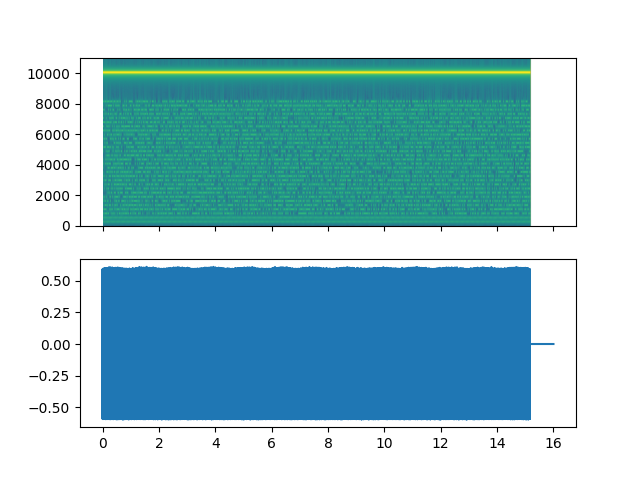

In [7]:
show_file(C.AUD_OUT_PATH)